19.1 Motivation

Force-directed layouts are not unique representations of a network. Different algorithms optimise different objectives and can reveal different structural properties. Since this project aims to communicate the historical structure of Broadway rather than perform additional statistical analysis, several layouts are compared before selecting one for the final interactive visualisation.

# 19.2 Experimental Design

This notebook compares several layout algorithms for visualising the Broadway performer collaboration network. The purpose is to identify a layout that best communicates the large-scale historical structure of the network while remaining computationally feasible.

## Fixed across all experiments
Analytical graph (55k nodes, 1.56M edges)
Node sizes
Node colours
Labels
Export format
Sigma renderer

## Varied
Layout algorithm
Edge-weight transformation (later)
Layout graph filtering (later)

In [1]:
# ============================================================
# 19.3 Helper Functions
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt


def layout_to_dataframe(graph, layout):
    """
    Convert an igraph layout into a DataFrame of x/y coordinates.
    """
    coords = pd.DataFrame(layout.coords, columns=["x", "y"])

    coords.insert(
        0,
        "id",
        graph.vs["id"]
    )

    return coords


def plot_layout(layout, title="", figsize=(10, 10), node_size=1):
    """
    Quick matplotlib preview of an igraph layout.
    Intended for rapid comparison, not publication-quality figures.
    """
    coords = layout.coords

    x = [p[0] for p in coords]
    y = [p[1] for p in coords]

    plt.figure(figsize=figsize)
    plt.scatter(
        x,
        y,
        s=node_size,
        alpha=0.6,
        linewidths=0
    )

    plt.title(title)
    plt.axis("equal")
    plt.axis("off")
    plt.show()


def export_layout(graph, layout, filename):
    """
    Save performer IDs and coordinates to CSV.
    """
    df = layout_to_dataframe(graph, layout)
    df.to_csv(filename, index=False)

    print(f"✓ Saved {len(df):,} coordinates to '{filename}'")

# 19.4

This section loads the cleaned Broadway collaboration network and prepares it for layout generation. Unless otherwise stated, all subsequent layout algorithms operate on this graph so that differences in the resulting visualisations can be attributed solely to the layout method.

In [2]:
import igraph as ig
import pandas as pd

g = ig.Graph.Read_GraphML("data/processed/broadway_network_clean.graphml")

print(g.summary())

IGRAPH U-W- 55261 1565292 -- 
+ attr: id (v), performer_name (v), weight (e)


In [3]:
print(f"Nodes: {g.vcount():,}")
print(f"Edges: {g.ecount():,}")

components = g.connected_components()

print(f"Connected components: {len(components)}")
print(f"Largest component: {max(components.sizes()):,} nodes")

Nodes: 55,261
Edges: 1,565,292
Connected components: 285
Largest component: 52,874 nodes


In [4]:
print(g.vs.attributes())
print(g.es.attributes())

['performer_name', 'id']
['weight']


# 19.5 LGL

## Algorithm
The Large Graph Layout (LGL) algorithm is designed specifically for large networks. It uses a spanning-tree approach to produce layouts efficiently for graphs containing tens of thousands of nodes. Because of its scalability, it serves as the baseline against which alternative layouts will be compared.

Generating LGL layout...


/Users/meiayong/Documents/VSCode Projects/mapping-the-broadway-network/venv/lib/python3.14/site-packages/igraph/layout.py:705: RuntimeWarning: LGL layout does not support disconnected graphs yet. Location: src/layout/large_graph.c:175
  layout = func(*args, **kwds)


✓ Layout generated in 50.86 seconds


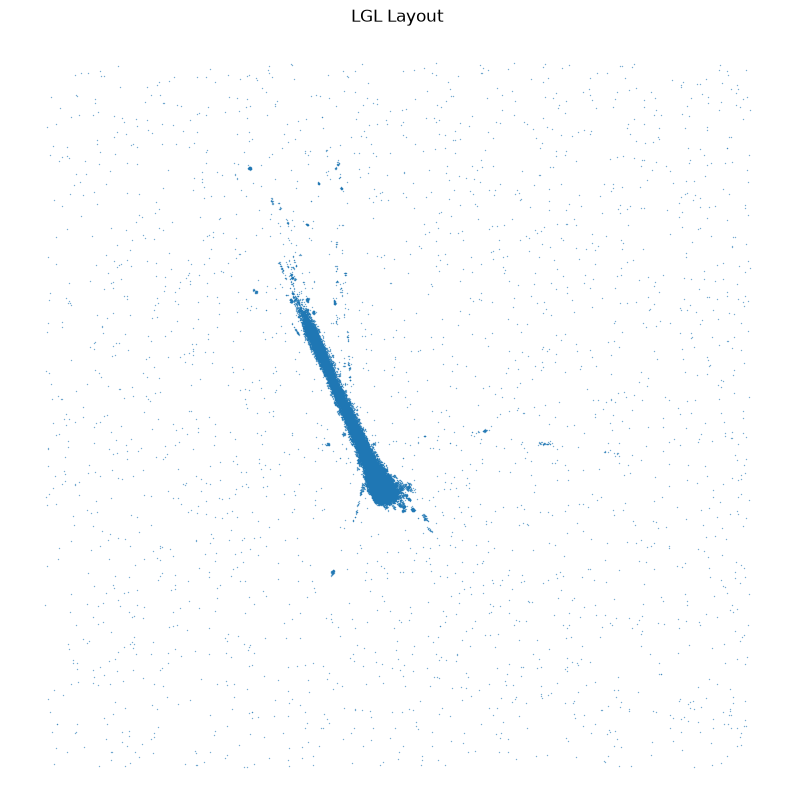

✓ Saved 55,261 coordinates to '../data/layouts/coordinates/lgl.csv'
✓ LGL experiment complete.


In [6]:
# ============================================================
# 19.5 Baseline Layout: LGL
# ============================================================

import os
import time

# Create output directory if it doesn't already exist
os.makedirs("../data/layouts/coordinates", exist_ok=True)

# ------------------------------------------------------------
# Generate layout
# ------------------------------------------------------------

print("Generating LGL layout...")

start = time.time()

layout_lgl = g.layout_lgl()

runtime = time.time() - start

print(f"✓ Layout generated in {runtime:.2f} seconds")

# ------------------------------------------------------------
# Preview layout
# ------------------------------------------------------------

plot_layout(
    layout_lgl,
    title="LGL Layout"
)

# ------------------------------------------------------------
# Export coordinates
# ------------------------------------------------------------

export_layout(
    g,
    layout_lgl,
    "../data/layouts/coordinates/lgl.csv"
)

print("✓ LGL experiment complete.")

# Observations

Runtime: 56.86 seconds

## Overall appearance:
The LGL layout successfully generates coordinates for the full Broadway collaboration network within a reasonable timeframe. However, the majority of the network remains concentrated into a dense central region corresponding to the giant connected component. Individual performers within this core are difficult to distinguish, and the overall structure appears visually compressed.

## Strengths
Scales effectively to a network of approximately 55,000 nodes.
Produces coordinates quickly enough for iterative experimentation.
Preserves the overall connected structure of the network.

## Weaknesses
Compresses the giant connected component into a dense central mass.
Provides limited separation between highly connected performers.
Makes historical communities and collaboration clusters difficult to identify.

# Suitability for final visualisation
LGL is not suitable for the final interactive visualisation. While computationally efficient, it does not provide sufficient spatial separation to communicate the structure of the Broadway collaboration network.

# 19.6 DRL

## Algorithm
iGraph's Distributed Recursive Layout (DRL) is specifically designed for large graphs and often does a better job of spreading large networks out than LGL. It may take longer, though.

Generating DRL layout...
✓ Layout generated in 180.59 seconds


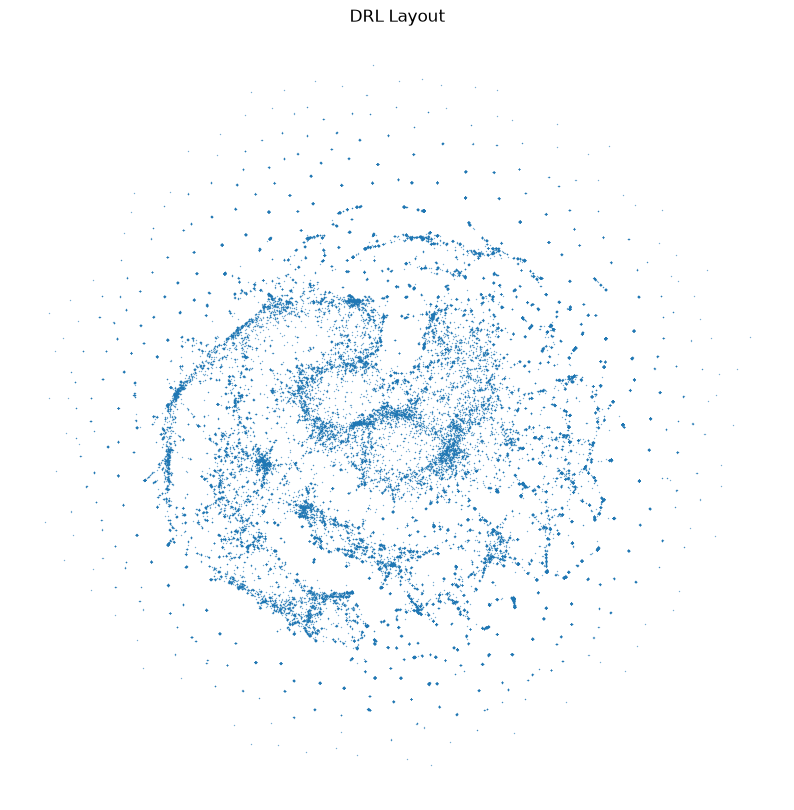

✓ Saved 55,261 coordinates to '../data/layouts/coordinates/drl.csv'
✓ DRL experiment complete.


In [5]:
# ============================================================
# 19.6 Layout Experiment: DRL
# ============================================================

import time

print("Generating DRL layout...")

start = time.time()

layout_drl = g.layout_drl()

runtime = time.time() - start

print(f"✓ Layout generated in {runtime:.2f} seconds")


plot_layout(
    layout_drl,
    title="DRL Layout"
)


export_layout(
    g,
    layout_drl,
    "../data/layouts/coordinates/drl.csv"
)

print("✓ DRL experiment complete.")

# Observations

Runtime: 180.59 seconds

## Overall appearance:
The DRL layout substantially improves spatial separation compared with LGL. Rather than collapsing the giant connected component into a single dense mass, DRL distributes the network across a larger area with visible variations in density. The resulting structure resembles a continuous collaboration landscape, with sparse peripheral regions surrounding denser central regions.

## Strengths
Produces substantially greater separation of the giant connected component.
Reveals meaningful variations in network density.
Preserves the overall connected structure while allowing lower-density regions to emerge.
Remains computationally feasible for a network of this size.

## Weaknesses
The full network remains visually dense when all nodes are rendered equally.
Individual important performers cannot yet be distinguished without node scaling and styling.
Dense core regions still require interactive exploration.

## Suitability for final visualisation
DRL is a strong candidate for the final visualisation. While the raw coordinate plot remains dense, the layout successfully reveals large-scale spatial structure and provides a more useful foundation for an interactive network atlas than LGL.

# 19.7 GraphOpt Layout

GraphOpt is an optimization-based force layout designed to improve graph readability by minimizing an energy function over node positions.

Unlike LGL and DRL, which are primarily designed for large-scale graph exploration, GraphOpt attempts to optimize the spatial arrangement more explicitly.

The goal of this experiment is to test whether GraphOpt can preserve the large-scale structure of the Broadway collaboration ecosystem while creating clearer separation between dense historical clusters.

In [ ]:
# ============================================================
# 19.7 Layout Experiment: GraphOpt
# ============================================================

import time

print("Generating GraphOpt layout...")

start = time.time()

layout_graphopt = g.layout_graphopt()

runtime = time.time() - start

print(f"✓ GraphOpt completed in {runtime:.2f} seconds")


plot_layout(
    layout_graphopt,
    title="GraphOpt Layout"
)


export_layout(
    g,
    layout_graphopt,
    "../data/layouts/coordinates/graphopt.csv"
)

print("✓ GraphOpt experiment complete.")

## Observations — GraphOpt Layout

### Runtime

GraphOpt was unable to complete within a practical timeframe on the full Broadway collaboration network.

The layout generation exceeded 45 minutes before being interrupted.

### Overall Appearance

No visual assessment was possible because the algorithm did not complete.

### Strengths

GraphOpt may be suitable for smaller subgraphs or filtered networks where computational requirements are reduced.

### Weaknesses

The algorithm was computationally impractical for the full-scale network:

- 55,173 nodes
- 1,565,292 edges

### Suitability for Final Visualisation

Rejected for the full Broadway network visualisation.

Future experiments should prioritise layouts that scale to tens of thousands of nodes while maintaining structural readability.

# 19.8 Fruchterman–Reingold

Fruchterman–Reingold is a classical force-directed algorithm.

It models the network as a physical system:

- connected nodes attract each other
- disconnected nodes repel each other
- the final layout attempts to balance these forces

This experiment tests whether a traditional force-directed approach can reveal meaningful structure in the Broadway performer collaboration network.

Evaluation criteria:

- Runtime
- Global separation
- Visibility of dense regions
- Preservation of collaboration neighbourhoods
- Suitability for Sigma.js visualisation

Generating Fruchterman-Reingold layout...
✓ FR completed in 7.85 seconds


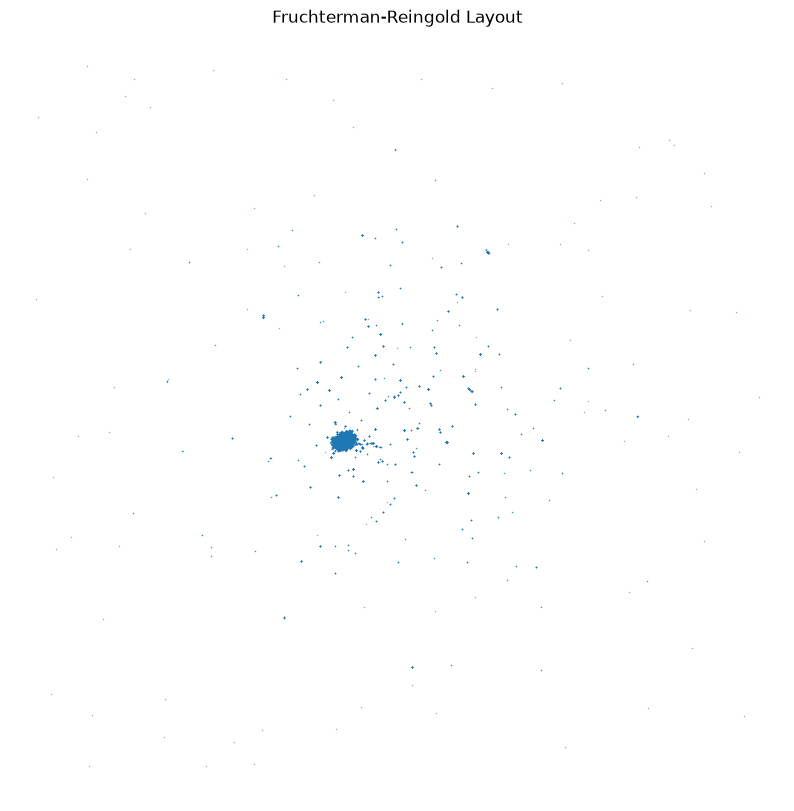

✓ Saved 55,261 coordinates to '../data/layouts/coordinates/fruchterman_reingold.csv'
✓ FR experiment complete.


In [10]:
# ============================================================
# 19.8 Layout Experiment: Fruchterman-Reingold
# ============================================================

import time

print("Generating Fruchterman-Reingold layout...")

start = time.time()

layout_fr = g.layout_fruchterman_reingold(
    weights="weight"
)

runtime = time.time() - start

print(f"✓ FR completed in {runtime:.2f} seconds")


plot_layout(
    layout_fr,
    title="Fruchterman-Reingold Layout"
)


export_layout(
    g,
    layout_fr,
    "../data/layouts/coordinates/fruchterman_reingold.csv"
)

print("✓ FR experiment complete.")

# Observations — Fruchterman-Reingold Layout

## Runtime

FR completed in 7.85 seconds.

## Overall Appearance

The layout produced a highly compact representation of the Broadway collaboration network.

Unlike DRL, the layout did not create substantial spatial separation between regions of the graph. The majority of nodes collapsed into a dense central mass.

## Strengths

- Extremely fast compared with other tested layouts
- Simple and scalable
- Preserves basic local connectivity

## Weaknesses

- Severe central compression
- Limited visibility of network structure
- Dense regions overlap heavily
- Poor representation of a large historical collaboration ecosystem

## Suitability for Final Visualisation

Rejected for the full Broadway network visualisation.

Although computationally efficient, the resulting structure does not provide sufficient visual separation for an interactive historical atlas.

# 19.9 DRL with log-transformed weights

In [ ]:
import numpy as np

g_log = g.copy()

g_log.es["log_weight"] = [
    np.log1p(w) for w in g.es["weight"]
]

In [ ]:
layout_drl_log = g_log.layout_drl(
    weights="log_weight"
)

: 